## MLS Player Statistics: Relationship between salary and game performance (xG, xA, match rating)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns
import numpy as np
import kagglehub

c:\Users\Eddie\miniconda3\envs\mls-statistics\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import and Clean Data

In [3]:
# import salary data
salary_2007 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2007.csv').assign(year=2007)
salary_2008 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2008.csv').assign(year=2008)
salary_2009 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2009.csv').assign(year=2009)
salary_2010 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2010.csv').assign(year=2010)
salary_2011 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2011.csv').assign(year=2011)
salary_2012 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2012.csv').assign(year=2012)
salary_2013 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2013.csv').assign(year=2013)
salary_2014 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2014.csv').assign(year=2014)
salary_2015 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2015.csv').assign(year=2015)
salary_2016 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2016.csv').assign(year=2016)
salary_2017 = pd.read_csv('C:/Users/Eddie/.cache/kagglehub/datasets/crawford/us-major-league-soccer-salaries/versions/1/mls-salaries-2017.csv').assign(year=2017)

salary = pd.concat([salary_2007, salary_2008, salary_2009, salary_2010, salary_2011, salary_2012, salary_2013, salary_2014, salary_2015, salary_2016, salary_2017], ignore_index=True)
salary = salary[(salary['club'].notna()) & (salary['base_salary'].notna())]

# import player data
players = pd.read_csv('data/all_players.csv')
players_07_17 = players[players['Year'].between(2007, 2017)]

# import match rating data / currently not feasible

In [4]:
# every post-season record is missing the team column
def assign_post_team(record):
    if (pd.isna(record['Club'])) & (record['Season']=='post'):
        record['Club'] = players_07_17[(players_07_17['Player']==record['Player']) & (players_07_17['Year']==record['Year'])].iloc[0]['Club']
    return record

players_07_17 = players_07_17.apply(lambda x: assign_post_team(x), axis=1)
print(len(players_07_17))

8015


In [5]:
ex_row = players_07_17[players_07_17['Player']=='Brad Evans'].iloc[15:17]
ex_row.apply(lambda x: assign_post_team(x), axis=1)

,Player,Club,POS,GP,GS,MINS,G,A,SHTS,SOG,...,RdA,A/90min,FC,FS,OFF,YC,RC,SOG%,Year,Season
12423,Brad Evans,SEA,D-M,4,4,360,0,1,6,4,...,1,0.25,5,4,0,1,0,66.67,2012,post
12685,Brad Evans,SEA,D-M,3,3,270,1,1,8,2,...,0,0.33,4,6,0,0,0,25.00,2013,post


In [6]:
# merge on name
salary['Name'] = salary['first_name'] + ' ' + salary['last_name']
player_and_salary = players_07_17.merge(salary, left_on=['Player', 'Club', 'Year'], right_on=['Name', 'club', 'year'], how='left')
print(len(player_and_salary))
player_and_salary.head(4)

# find NaN
print("NaN: " + str(player_and_salary['base_salary'].isna().sum()))
print("Len: " + str(len(player_and_salary)))

# # # clean up
player_and_salary = player_and_salary.drop(columns=['Name', 'year'])
player_and_salary = player_and_salary[(player_and_salary['base_salary'].notna()) & (player_and_salary['Club'].notna())]
print(len(player_and_salary))

8015
NaN: 4355
Len: 8015
3660


In [7]:
grouped_player_and_salary = player_and_salary.groupby(['Player', 'Year', 'POS','club'])[['GP', 'GS', 'MINS', 'G', 'A', 'G/90min', 'A/90min', 'GWG', 'GWA', 'HmG', 'RdG', 'HmA', 'RdA', 'base_salary', 'guaranteed_compensation']].agg('sum').reset_index()
seasons = grouped_player_and_salary
seasons.head(3)

,Player,Year,POS,club,GP,GS,MINS,G,A,G/90min,A/90min,GWG,GWA,HmG,RdG,HmA,RdA,base_salary,guaranteed_compensation
0,AJ Cochran,2014,D,HOU,19,14,1370,0,0,0.0,0.0,0,0,0,0,0,0,57500.0,73500.0
1,AJ Cochran,2015,D,HOU,7,5,512,0,0,0.0,0.0,0,0,0,0,0,0,60375.0,76375.0
2,Aaron Guillen,2016,D,DAL,2,1,106,0,0,0.0,0.0,0,0,0,0,0,0,103000.0,103000.0


In [8]:
len(grouped_player_and_salary)

2404

## Most Productive Seasons

In [9]:
# seasons with the highest G/90 and A/90
seasons['G+A'] = seasons['G'] + seasons['A']
seasons.sort_values(by=['G+A'], ascending=False).iloc[0:18]

,Player,Year,POS,club,GP,GS,MINS,G,A,G/90min,A/90min,GWG,GWA,HmG,RdG,HmA,RdA,base_salary,guaranteed_compensation,G+A
2115,Sebastian Giovinco,2016,F,TOR,34,34,2975,21,19,1.28,1.21,5,6,11,10,9,10,11200000.00,14231111.34,40
2114,Sebastian Giovinco,2015,F,TOR,34,33,2865,22,16,0.71,0.52,7,1,12,10,9,7,11200000.00,14231111.34,38
546,Chris Wondolowski,2012,F,SJ,34,33,2993,27,7,0.86,0.22,11,0,13,14,4,3,600000.00,600000.00,34
818,Diego Valeri,2017,M,POR,34,34,3008,21,12,0.67,0.85,7,3,13,8,8,4,4455000.00,5215000.00,33
1066,Guillermo Barros Schelotto,2008,F,CLB,31,31,2561,7,25,0.28,2.34,1,7,5,2,19,6,500000.00,750000.00,32
1818,Obafemi Martins,2014,F,SEA,35,33,2960,17,13,0.59,0.45,3,4,7,10,7,6,3240000.00,3506666.66,30
1112,Ignacio Piatti,2016,M,MTL,37,36,3292,21,8,1.30,0.57,6,1,8,13,6,2,850000.00,850000.00,29
431,Camilo Sanvezzo,2013,F,VAN,32,27,2418,22,6,0.82,0.22,5,2,14,8,3,3,210000.00,247500.00,28
1786,Nemanja Nikolic,2017,F,CHI,35,35,3036,24,4,0.73,0.12,5,1,19,5,2,2,3400000.08,3812666.74,28
2321,Victor Vazquez,2017,M,TOR,36,33,2807,10,17,0.72,0.81,5,7,6,4,10,7,1260000.00,1400000.00,27


In [14]:
seasons.to_csv("data/seasons.csv", index=False)

## Does Salary have a relationship with Overall Performance?

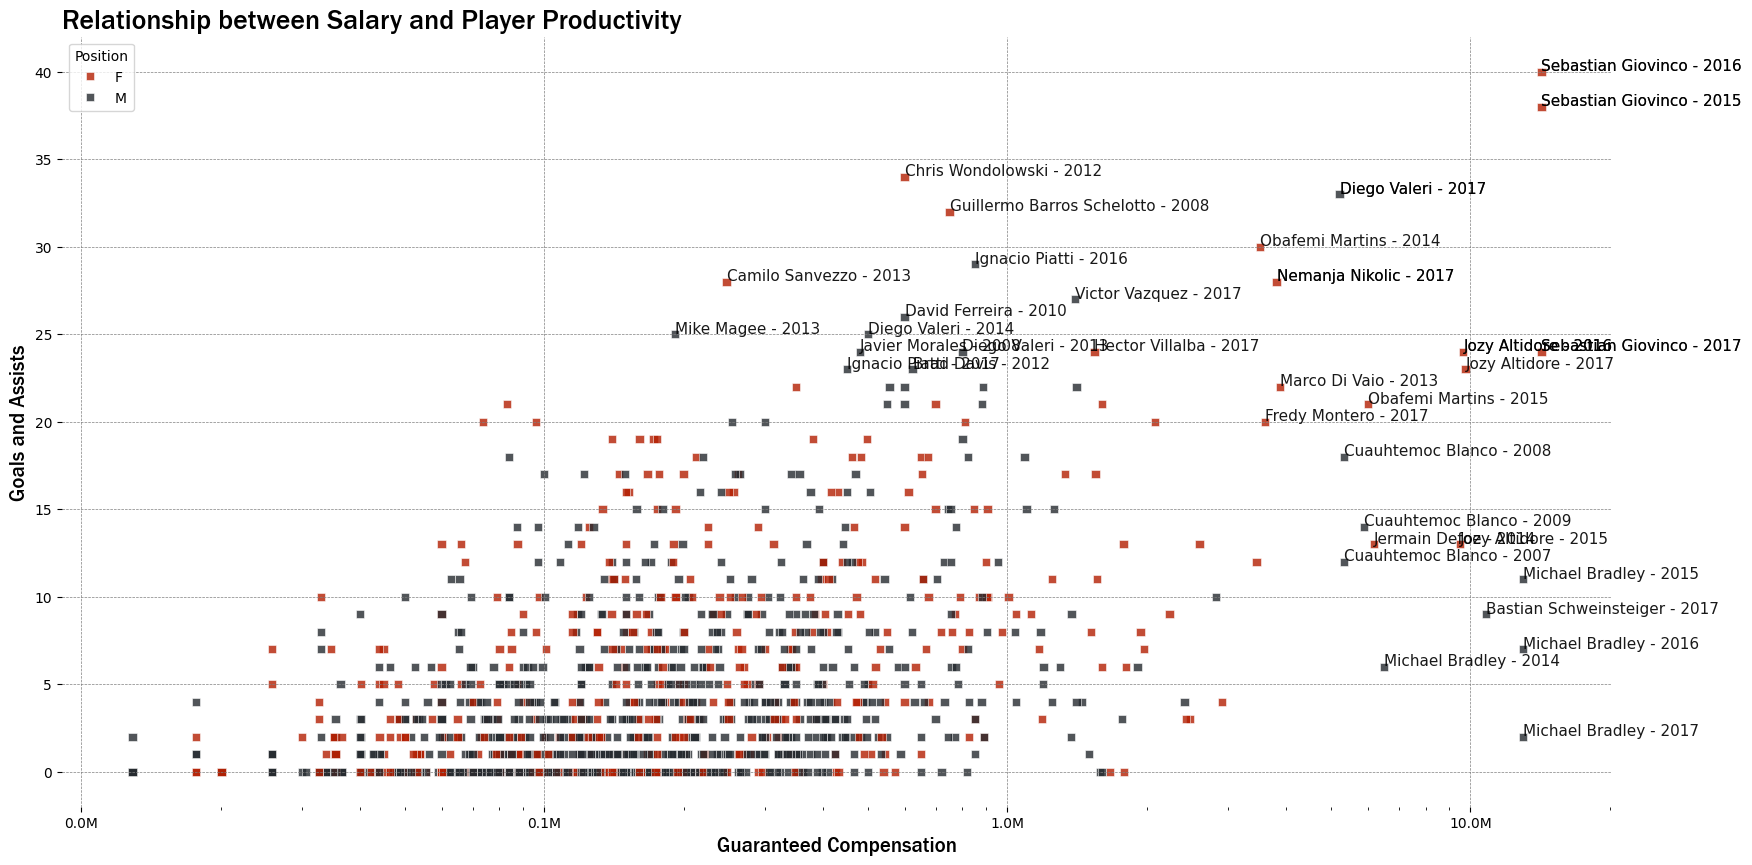

In [11]:
# scatter plot of guaranteed compensation vs. G+A
#filter for midfielders and forwards
f, ax = plt.subplots(figsize=(20, 10))
mf = seasons[(seasons['POS']=='F') | (seasons['POS']=='M')]

# plot 
sns.scatterplot(data=mf, x='guaranteed_compensation', y='G+A', hue='POS', palette=['#b31f02', '#262b30'], marker='s', alpha=.8)

# titles
plt.xlabel('Guaranteed Compensation', fontname = 'Franklin Gothic Medium', fontsize=15)
plt.ylabel('Goals and Assists', fontname='Franklin Gothic Medium', fontsize=15)
plt.title('Relationship between Salary and Player Productivity', fontname='Franklin Gothic Medium', fontsize=20, loc='left')


# label points
def label_point(x, y, player, year, ax):
    a = pd.concat({'x':x, 'y':y, 'player':player, 'year':year}, axis=1)
    for i, point in a.iterrows():
        label = f"{point['player']} - {point['year']}"
        ax.text(point['x'] + .05, point['y'] + .05, label, fontsize=11, alpha=.9)

top = pd.concat(
    [
        mf.nlargest(20, 'guaranteed_compensation'),
        mf.nlargest(20, 'G+A')
    ],
    axis=0
)

label_point(top['guaranteed_compensation'], top['G+A'], top['Player'], top['Year'], plt.gca())

# remove spines
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# set log to show relationships better
ax.set_xscale('log')

# set grid
plt.gca().set_facecolor('white')
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=0.5)
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
#legend
plt.legend(title='Position', loc='upper left',)



plt.show()

I think this plot might look better in d3. Make a webpage with toggle for the y-axis. 

In [12]:
#  year vs average team salary

In [13]:
# ML predict player salary based on win percentage, goals, assists
